<a href="https://colab.research.google.com/github/rudalshan0412-code/attention-is-all-you-need-pytorch/blob/main/15)_Transformer%EA%B3%BC_%EB%B9%84%EA%B5%90.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Google Drive 연결

from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# 프로젝트 경로 설정

from pathlib import Path
import sys

PROJECT_ROOT = Path(
    "/content/drive/MyDrive/attention_is_all_you_need"
)

SRC_DIR = PROJECT_ROOT / "src"

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(
        0,
        str(PROJECT_ROOT),
    )

print("PROJECT_ROOT:", PROJECT_ROOT)
print("SRC_DIR:", SRC_DIR)
print("PROJECT_ROOT exists:", PROJECT_ROOT.exists())
print("SRC_DIR exists:", SRC_DIR.exists())

PROJECT_ROOT: /content/drive/MyDrive/attention_is_all_you_need
SRC_DIR: /content/drive/MyDrive/attention_is_all_you_need/src
PROJECT_ROOT exists: True
SRC_DIR exists: True


In [ ]:
# 기존 src 파일 목록 확인

src_files = sorted(
    file.name
    for file in SRC_DIR.glob("*.py")
)

for file_name in src_files:
    print(file_name)

attention.py
dataset.py
decoder.py
decoder_layer.py
encoder.py
encoder_layer.py
feed_forward.py
mask.py
multi_head_attention.py
positional_encoding.py
tokenizer.py
transformer.py
vocabulary.py


In [ ]:
# Pytorch 버전 확인

import torch

print("PyTorch version:", torch.__version__)
# PyTorch version: 2.11.0+cu128

PyTorch version: 2.11.0+cu128


In [ ]:
# 모듈 import

import math

import torch
import torch.nn as nn

from src.transformer import Transformer
from src.positional_encoding import PositionalEncoding

from src.tokenizer import tokenize

from src.vocabulary import (
    Vocabulary,
    PAD_IDX,
    UNK_IDX,
    BOS_IDX,
    EOS_IDX,
)

from src.dataset import TranslationDataset

from src.mask import (
    create_padding_mask,
    create_causal_mask,
)

print("Imports successful")

Imports successful


In [ ]:
# Special Token index 확인

print("PAD_IDX:", PAD_IDX)
print("UNK_IDX:", UNK_IDX)
print("BOS_IDX:", BOS_IDX)
print("EOS_IDX:", EOS_IDX)

PAD_IDX: 0
UNK_IDX: 1
BOS_IDX: 2
EOS_IDX: 3


In [ ]:
# Custom EncoderLayer 확인

encoder_layer_path = SRC_DIR / "encoder_layer.py"

print(
    encoder_layer_path.read_text(
        encoding="utf-8"
    )
)


import torch.nn as nn

from src.multi_head_attention import MultiHeadAttention
from src.feed_forward import PositionwiseFeedForward


class EncoderLayer(nn.Module):
    def __init__(
        self,
        d_model,
        num_heads,
        d_ff,
        dropout=0.1,
    ):
        super().__init__()

        self.self_attention = MultiHeadAttention(
            d_model,
            num_heads,
        )

        self.feed_forward = PositionwiseFeedForward(
            d_model,
            d_ff,
        )

        self.dropout1 = nn.Dropout(dropout)
        self.dropout2 = nn.Dropout(dropout)

        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)

    def forward(self, x, mask=None):
        # 1. Multi-Head Self-Attention
        attention_output, attention_weights = self.self_attention(
            x,
            x,
            x,
            mask,
        )

        # 2. 첫 번째 Add & Norm
        attention_output = self.dropout1(attention_output)

      

In [ ]:
# 실제 Custom DecoderLayer 확인

decoder_layer_path = SRC_DIR / "decoder_layer.py"

print(
    decoder_layer_path.read_text(
        encoding="utf-8"
    )
)


import torch.nn as nn

from src.multi_head_attention import MultiHeadAttention
from src.feed_forward import PositionwiseFeedForward


class DecoderLayer(nn.Module):
    def __init__(
        self,
        d_model,
        num_heads,
        d_ff,
        dropout=0.1,
    ):
        super().__init__()

        self.self_attention = MultiHeadAttention(
            d_model,
            num_heads,
        )

        self.cross_attention = MultiHeadAttention(
            d_model,
            num_heads,
        )

        self.feed_forward = PositionwiseFeedForward(
            d_model,
            d_ff,
        )

        self.dropout1 = nn.Dropout(dropout)
        self.dropout2 = nn.Dropout(dropout)
        self.dropout3 = nn.Dropout(dropout)

        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.norm3 = nn.LayerNorm(d_model)

    def forward(
        self,
        x,
        encoder_output,
        self_attention_mask=None,
        cross_atten

In [ ]:
# 실제 Feed Forward activation 확인

feed_forward_path = SRC_DIR / "feed_forward.py"

print(
    feed_forward_path.read_text(
        encoding="utf-8"
    )
)


import torch.nn as nn
import torch.nn.functional as F


class PositionwiseFeedForward(nn.Module):
    """
    Position-wise Feed Forward Network.

    Input:
        (batch_size, seq_len, d_model)

    Output:
        (batch_size, seq_len, d_model)
    """

    def __init__(self, d_model, d_ff):
        super().__init__()

        self.linear1 = nn.Linear(d_model, d_ff)
        self.linear2 = nn.Linear(d_ff, d_model)

    def forward(self, x):
        x = self.linear1(x)
        x = F.relu(x)
        x = self.linear2(x)

        return x



In [ ]:
# 실제 Custom Transformer API 확인

transformer_path = SRC_DIR / "transformer.py"

print(
    transformer_path.read_text(
        encoding="utf-8"
    )
)


import math

import torch.nn as nn

from src.positional_encoding import PositionalEncoding
from src.encoder import Encoder
from src.decoder import Decoder


class Transformer(nn.Module):
    def __init__(
        self,
        source_vocab_size,
        target_vocab_size,
        d_model,
        num_heads,
        d_ff,
        num_encoder_layers,
        num_decoder_layers,
        max_len,
        dropout=0.1,
    ):
        super().__init__()

        self.d_model = d_model

        self.source_embedding = nn.Embedding(
            source_vocab_size,
            d_model,
        )

        self.target_embedding = nn.Embedding(
            target_vocab_size,
            d_model,
        )

        self.source_positional_encoding = PositionalEncoding(
            d_model,
            max_len,
            dropout,
        )

        self.target_positional_encoding = PositionalEncoding(
            d_model,
            max_len,
            dropout,
        )

        self.encoder = En

In [ ]:
# Pytorch wrapper 구조 설계

import math

import torch.nn as nn

from src.positional_encoding import PositionalEncoding


class PyTorchTransformer(nn.Module):
    def __init__(
        self,
        source_vocab_size,
        target_vocab_size,
        d_model,
        num_heads,
        d_ff,
        num_encoder_layers,
        num_decoder_layers,
        max_len,
        dropout=0.1,
    ):
        super().__init__()

        self.d_model = d_model

        self.source_embedding = nn.Embedding(
            source_vocab_size,
            d_model,
        )

        self.target_embedding = nn.Embedding(
            target_vocab_size,
            d_model,
        )

        self.source_positional_encoding = PositionalEncoding(
            d_model,
            max_len,
            dropout,
        )

        self.target_positional_encoding = PositionalEncoding(
            d_model,
            max_len,
            dropout,
        )

        self.transformer = nn.Transformer(
            d_model=d_model,
            nhead=num_heads,
            num_encoder_layers=num_encoder_layers,
            num_decoder_layers=num_decoder_layers,
            dim_feedforward=d_ff,
            dropout=dropout,
            activation="relu",
            batch_first=True,
            norm_first=False,
        )

        self.output_projection = nn.Linear(
            d_model,
            target_vocab_size,
        )

    def forward(
        self,
        source_token_ids,
        target_token_ids,
        src_key_padding_mask=None,
        tgt_key_padding_mask=None,
        memory_key_padding_mask=None,
        tgt_mask=None,
    ):
        source_x = self.source_embedding(
            source_token_ids
        )

        source_x = (
            source_x
            * math.sqrt(self.d_model)
        )

        source_x = self.source_positional_encoding(
            source_x
        )

        target_x = self.target_embedding(
            target_token_ids
        )

        target_x = (
            target_x
            * math.sqrt(self.d_model)
        )

        target_x = self.target_positional_encoding(
            target_x
        )

        transformer_output = self.transformer(
            src=source_x,
            tgt=target_x,
            src_key_padding_mask=src_key_padding_mask,
            tgt_key_padding_mask=tgt_key_padding_mask,
            memory_key_padding_mask=memory_key_padding_mask,
            tgt_mask=tgt_mask,
        )

        logits = self.output_projection(
            transformer_output
        )

        return logits

In [ ]:
# 토이데이터 생성

# 이전 단계에서 사용한 데이터와 동일한 데이터를 사용한다

sentence_pairs = [
    ("I am happy.", "나는 행복하다."),
    ("You are happy.", "너는 행복하다."),
    ("I like apples.", "나는 사과를 좋아한다."),
    ("I read a book.", "나는 책을 읽는다."),
    ("I am tired.", "나는 피곤하다."),
    ("You are tired.", "너는 피곤하다."),
    ("I like bananas.", "나는 바나나를 좋아한다."),
    ("I drink water.", "나는 물을 마신다."),
    ("I eat rice.", "나는 밥을 먹는다."),
    ("I am hungry.", "나는 배고프다."),
    ("You are hungry.", "너는 배고프다."),
    ("I am busy.", "나는 바쁘다."),
    ("You are busy.", "너는 바쁘다."),
    ("I like coffee.", "나는 커피를 좋아한다."),
    ("I like tea.", "나는 차를 좋아한다."),
    ("I study English.", "나는 영어를 공부한다."),
    ("I study math.", "나는 수학을 공부한다."),
    ("I watch TV.", "나는 텔레비전을 본다."),
    ("I watch a movie.", "나는 영화를 본다."),
    ("I listen to music.", "나는 음악을 듣는다."),
    ("I play soccer.", "나는 축구를 한다."),
    ("I play basketball.", "나는 농구를 한다."),
    ("I go to school.", "나는 학교에 간다."),
    ("I go home.", "나는 집에 간다."),
    ("I see a dog.", "나는 개를 본다."),
    ("I see a cat.", "나는 고양이를 본다."),
    ("I have a book.", "나는 책을 가지고 있다."),
    ("I have a pen.", "나는 펜을 가지고 있다."),
    ("You have a book.", "너는 책을 가지고 있다."),
    ("You have a pen.", "너는 펜을 가지고 있다."),
    ("We study together.", "우리는 함께 공부한다."),
    ("We eat together.", "우리는 함께 먹는다."),
    ("We are happy.", "우리는 행복하다."),
    ("They are happy.", "그들은 행복하다."),
    ("They are busy.", "그들은 바쁘다."),
    ("He reads a book.", "그는 책을 읽는다."),
    ("She reads a book.", "그녀는 책을 읽는다."),
    ("He drinks water.", "그는 물을 마신다."),
    ("She drinks water.", "그녀는 물을 마신다."),
    ("He likes apples.", "그는 사과를 좋아한다."),
    ("She likes apples.", "그녀는 사과를 좋아한다."),
    ("The dog is small.", "그 개는 작다."),
    ("The cat is small.", "그 고양이는 작다."),
    ("The dog is big.", "그 개는 크다."),
    ("The cat is big.", "그 고양이는 크다."),
    ("This is a book.", "이것은 책이다."),
    ("This is a pen.", "이것은 펜이다."),
    ("That is a dog.", "저것은 개다."),
    ("That is a cat.", "저것은 고양이다."),
    ("Today is good.", "오늘은 좋다."),
]

validation_indices = [
    4,
    9,
    14,
    18,
    23,
    31,
    36,
    39,
    42,
    47,
]

train_pairs = [
    pair
    for index, pair in enumerate(sentence_pairs)
    if index not in validation_indices
]

validation_pairs = [
    sentence_pairs[index]
    for index in validation_indices
]

print("전체:", len(sentence_pairs))
print("Train:", len(train_pairs))
print("Validation:", len(validation_pairs))

assert len(sentence_pairs) == 50
assert len(train_pairs) == 40
assert len(validation_pairs) == 10

전체: 50
Train: 40
Validation: 10


In [ ]:
# Train 기준 Source / Target Vocabulary 생성

from src.tokenizer import tokenize
from src.vocabulary import Vocabulary

train_source_sentences = [
    source
    for source, target in train_pairs
]

train_target_sentences = [
    target
    for source, target in train_pairs
]

validation_source_sentences = [
    source
    for source, target in validation_pairs
]

validation_target_sentences = [
    target
    for source, target in validation_pairs
]

source_tokenized = [
    tokenize(sentence)
    for sentence in train_source_sentences
]

target_tokenized = [
    tokenize(sentence)
    for sentence in train_target_sentences
]

source_vocab = Vocabulary(
    source_tokenized
)

target_vocab = Vocabulary(
    target_tokenized
)

print("Source vocab size:", len(source_vocab))
print("Target vocab size:", len(target_vocab))
print("Same object:", source_vocab is target_vocab)

Source vocab size: 58
Target vocab size: 55
Same object: False


In [ ]:
# Dataset / DataLoader 생성

from torch.utils.data import DataLoader

from src.dataset import (
    TranslationDataset,
    collate_fn,
)

train_dataset = TranslationDataset(
    train_source_sentences,
    train_target_sentences,
    tokenize,
    tokenize,
    source_vocab,
    target_vocab,
)

validation_dataset = TranslationDataset(
    validation_source_sentences,
    validation_target_sentences,
    tokenize,
    tokenize,
    source_vocab,
    target_vocab,
)

generator_custom = torch.Generator()
generator_custom.manual_seed(42)

generator_pytorch = torch.Generator()
generator_pytorch.manual_seed(42)

custom_train_loader = DataLoader(
    train_dataset,
    batch_size=8,
    shuffle=True,
    collate_fn=collate_fn,
    generator=generator_custom,
)

pytorch_train_loader = DataLoader(
    train_dataset,
    batch_size=8,
    shuffle=True,
    collate_fn=collate_fn,
    generator=generator_pytorch,
)

validation_loader = DataLoader(
    validation_dataset,
    batch_size=8,
    shuffle=False,
    collate_fn=collate_fn,
)

print(len(train_dataset))
print(len(validation_dataset))

40
10


In [ ]:
# Batch 하나 확인 + Target Shift

source_batch, target_batch = next(
    iter(custom_train_loader)
)

decoder_input = target_batch[:, :-1]
labels = target_batch[:, 1:]

print("source_batch:", source_batch.shape)
print("target_batch:", target_batch.shape)
print("decoder_input:", decoder_input.shape)
print("labels:", labels.shape)

print("source dtype:", source_batch.dtype)
print("target dtype:", target_batch.dtype)

assert decoder_input.size(1) == target_batch.size(1) - 1

assert source_batch.dtype == torch.long
assert target_batch.dtype == torch.long

source_batch: torch.Size([8, 7])
target_batch: torch.Size([8, 7])
decoder_input: torch.Size([8, 6])
labels: torch.Size([8, 6])
source dtype: torch.int64
target dtype: torch.int64


In [ ]:
# Custom Transformer 생성 + Parameter 수

from src.transformer import Transformer

torch.manual_seed(42)

custom_model = Transformer(
    source_vocab_size=len(source_vocab),
    target_vocab_size=len(target_vocab),
    d_model=64,
    num_heads=4,
    d_ff=128,
    num_encoder_layers=2,
    num_decoder_layers=2,
    max_len=50,
    dropout=0.1,
)

custom_parameter_count = sum(
    parameter.numel()
    for parameter in custom_model.parameters()
    if parameter.requires_grad
)

print(
    "Custom Transformer parameters:",
    custom_parameter_count,
)

Custom Transformer parameters: 178231


In [ ]:
# PytorchTransformer Wrapper 생성

import math
import torch.nn as nn

from src.positional_encoding import PositionalEncoding


class PyTorchTransformer(nn.Module):
    def __init__(
        self,
        source_vocab_size,
        target_vocab_size,
        d_model,
        num_heads,
        d_ff,
        num_encoder_layers,
        num_decoder_layers,
        max_len,
        dropout=0.1,
    ):
        super().__init__()

        self.d_model = d_model

        self.source_embedding = nn.Embedding(
            source_vocab_size,
            d_model,
        )

        self.target_embedding = nn.Embedding(
            target_vocab_size,
            d_model,
        )

        self.source_positional_encoding = PositionalEncoding(
            d_model,
            max_len,
            dropout,
        )

        self.target_positional_encoding = PositionalEncoding(
            d_model,
            max_len,
            dropout,
        )

        self.transformer = nn.Transformer(
            d_model=d_model,
            nhead=num_heads,
            num_encoder_layers=num_encoder_layers,
            num_decoder_layers=num_decoder_layers,
            dim_feedforward=d_ff,
            dropout=dropout,
            activation="relu",
            batch_first=True,
            norm_first=False,
        )

        self.output_projection = nn.Linear(
            d_model,
            target_vocab_size,
        )

    def forward(
        self,
        source_token_ids,
        target_token_ids,
        src_key_padding_mask=None,
        tgt_key_padding_mask=None,
        memory_key_padding_mask=None,
        tgt_mask=None,
    ):
        source_x = self.source_embedding(
            source_token_ids
        )

        source_x = (
            source_x
            * math.sqrt(self.d_model)
        )

        source_x = self.source_positional_encoding(
            source_x
        )

        target_x = self.target_embedding(
            target_token_ids
        )

        target_x = (
            target_x
            * math.sqrt(self.d_model)
        )

        target_x = self.target_positional_encoding(
            target_x
        )

        transformer_output = self.transformer(
            src=source_x,
            tgt=target_x,
            src_key_padding_mask=src_key_padding_mask,
            tgt_key_padding_mask=tgt_key_padding_mask,
            memory_key_padding_mask=memory_key_padding_mask,
            tgt_mask=tgt_mask,
        )

        logits = self.output_projection(
            transformer_output
        )

        return logits

# 생성

torch.manual_seed(42)

pytorch_model = PyTorchTransformer(
    source_vocab_size=len(source_vocab),
    target_vocab_size=len(target_vocab),
    d_model=64,
    num_heads=4,
    d_ff=128,
    num_encoder_layers=2,
    num_decoder_layers=2,
    max_len=50,
    dropout=0.1,
)

pytorch_parameter_count = sum(
    parameter.numel()
    for parameter in pytorch_model.parameters()
    if parameter.requires_grad
)

print(
    "PyTorch wrapper parameters:",
    pytorch_parameter_count,
)

PyTorch wrapper parameters: 178487


In [ ]:
# Parameter 수 비교

print(
    "Custom:",
    custom_parameter_count,
)

print(
    "PyTorch:",
    pytorch_parameter_count,
)

print(
    "Difference:",
    pytorch_parameter_count
    - custom_parameter_count,
)

Custom: 178231
PyTorch: 178487
Difference: 256


In [ ]:
# Pytorch Mask 생성/비교

from src.mask import (
    create_padding_mask,
    create_causal_mask,
)

custom_source_mask = create_padding_mask(
    source_batch,
    PAD_IDX,
)

custom_target_padding_mask = create_padding_mask(
    decoder_input,
    PAD_IDX,
)

custom_causal_mask = create_causal_mask(
    decoder_input.size(1),
    device=decoder_input.device,
)

custom_target_mask = (
    custom_target_padding_mask
    & custom_causal_mask
)

print(
    "Custom source mask:",
    custom_source_mask.shape,
)

print(
    "Custom target padding:",
    custom_target_padding_mask.shape,
)

print(
    "Custom causal:",
    custom_causal_mask.shape,
)

print(
    "Custom target mask:",
    custom_target_mask.shape,
)

Custom source mask: torch.Size([8, 1, 1, 7])
Custom target padding: torch.Size([8, 1, 1, 6])
Custom causal: torch.Size([1, 1, 6, 6])
Custom target mask: torch.Size([8, 1, 6, 6])


In [ ]:
# Pytorch Forward Test

# device 설정

device = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

print(device)

# 모델과 batch 이동

custom_model = custom_model.to(device)
pytorch_model = pytorch_model.to(device)

source_batch = source_batch.to(device)
target_batch = target_batch.to(device)

decoder_input = target_batch[:, :-1]
labels = target_batch[:, 1:]

# pytorch mask 재생성

src_key_padding_mask = (
    source_batch == PAD_IDX
)

tgt_key_padding_mask = (
    decoder_input == PAD_IDX
)

memory_key_padding_mask = (
    source_batch == PAD_IDX
)

tgt_len = decoder_input.size(1)

tgt_causal_mask = torch.triu(
    torch.ones(
        tgt_len,
        tgt_len,
        dtype=torch.bool,
        device=device,
    ),
    diagonal=1,
)

# forward

pytorch_model.eval()

with torch.no_grad():
    pytorch_logits = pytorch_model(
        source_batch,
        decoder_input,
        src_key_padding_mask=
            src_key_padding_mask,
        tgt_key_padding_mask=
            tgt_key_padding_mask,
        memory_key_padding_mask=
            memory_key_padding_mask,
        tgt_mask=tgt_causal_mask,
    )

print(
    "source_batch:",
    source_batch.shape,
)

print(
    "target_batch:",
    target_batch.shape,
)

print(
    "decoder_input:",
    decoder_input.shape,
)

print(
    "src padding mask:",
    src_key_padding_mask.shape,
)

print(
    "tgt padding mask:",
    tgt_key_padding_mask.shape,
)

print(
    "tgt causal mask:",
    tgt_causal_mask.shape,
)

print(
    "PyTorch logits:",
    pytorch_logits.shape,
)

print(
    pytorch_logits.size(-1)
    == len(target_vocab)
)

cuda


/usr/local/lib/python3.13/dist-packages/torch/nn/modules/transformer.py:531: UserWarning: The PyTorch API of nested tensors is in prototype stage and will change in the near future. We recommend specifying layout=torch.jagged when constructing a nested tensor, as this layout receives active development, has better operator coverage, and works with torch.compile. (Triggered internally at /pytorch/aten/src/ATen/NestedTensorImpl.cpp:178.)
  output = torch._nested_tensor_from_mask(


source_batch: torch.Size([8, 7])
target_batch: torch.Size([8, 7])
decoder_input: torch.Size([8, 6])
src padding mask: torch.Size([8, 7])
tgt padding mask: torch.Size([8, 6])
tgt causal mask: torch.Size([6, 6])
PyTorch logits: torch.Size([8, 6, 55])
True


In [ ]:
# Custom Forward Test

custom_source_mask = create_padding_mask(
    source_batch,
    PAD_IDX,
)

custom_target_padding_mask = create_padding_mask(
    decoder_input,
    PAD_IDX,
)

custom_causal_mask = create_causal_mask(
    decoder_input.size(1),
    device=device,
)

custom_target_mask = (
    custom_target_padding_mask
    & custom_causal_mask
)

custom_model.eval()

with torch.no_grad():
    (
        custom_logits,
        _,
        _,
        _,
    ) = custom_model(
        source_batch,
        decoder_input,
        custom_source_mask,
        custom_target_mask,
    )

print(
    "Custom logits:",
    custom_logits.shape,
)

print(
    custom_logits.size(-1)
    == len(target_vocab)
)

Custom logits: torch.Size([8, 6, 55])
True


In [ ]:
# Criterion + Initial Loss 비교

criterion = nn.CrossEntropyLoss(
    ignore_index=PAD_IDX
)

custom_initial_loss = criterion(
    custom_logits.reshape(
        -1,
        custom_logits.size(-1),
    ),
    labels.reshape(-1),
)

pytorch_initial_loss = criterion(
    pytorch_logits.reshape(
        -1,
        pytorch_logits.size(-1),
    ),
    labels.reshape(-1),
)

print(
    "Custom initial loss:",
    custom_initial_loss.item(),
)

print(
    "PyTorch initial loss:",
    pytorch_initial_loss.item(),
)

Custom initial loss: 4.014692783355713
PyTorch initial loss: 4.223791599273682


In [ ]:
# Optimizer 생성

custom_optimizer = torch.optim.Adam(
    custom_model.parameters(),
    lr=1e-3,
)

pytorch_optimizer = torch.optim.Adam(
    pytorch_model.parameters(),
    lr=1e-3,
)

In [ ]:
# Custom Transformer Training

custom_train_loss_history = []
custom_val_loss_history = []

num_epochs = 200

for epoch in range(
    1,
    num_epochs + 1,
):
    custom_model.train()

    train_loss_sum = 0.0

    for (
        source_batch,
        target_batch,
    ) in custom_train_loader:

        source_batch = source_batch.to(
            device
        )

        target_batch = target_batch.to(
            device
        )

        decoder_input = (
            target_batch[:, :-1]
        )

        labels = (
            target_batch[:, 1:]
        )

        source_mask = create_padding_mask(
            source_batch,
            PAD_IDX,
        )

        target_padding_mask = (
            create_padding_mask(
                decoder_input,
                PAD_IDX,
            )
        )

        causal_mask = create_causal_mask(
            decoder_input.size(1),
            device=device,
        )

        target_mask = (
            target_padding_mask
            & causal_mask
        )

        custom_optimizer.zero_grad()

        (
            logits,
            _,
            _,
            _,
        ) = custom_model(
            source_batch,
            decoder_input,
            source_mask,
            target_mask,
        )

        loss = criterion(
            logits.reshape(
                -1,
                logits.size(-1),
            ),
            labels.reshape(-1),
        )

        loss.backward()

        custom_optimizer.step()

        train_loss_sum += (
            loss.item()
        )

    custom_train_loss = (
        train_loss_sum
        / len(custom_train_loader)
    )

    custom_model.eval()

    validation_loss_sum = 0.0

    with torch.no_grad():
        for (
            source_batch,
            target_batch,
        ) in validation_loader:

            source_batch = (
                source_batch.to(device)
            )

            target_batch = (
                target_batch.to(device)
            )

            decoder_input = (
                target_batch[:, :-1]
            )

            labels = (
                target_batch[:, 1:]
            )

            source_mask = (
                create_padding_mask(
                    source_batch,
                    PAD_IDX,
                )
            )

            target_padding_mask = (
                create_padding_mask(
                    decoder_input,
                    PAD_IDX,
                )
            )

            causal_mask = (
                create_causal_mask(
                    decoder_input.size(1),
                    device=device,
                )
            )

            target_mask = (
                target_padding_mask
                & causal_mask
            )

            (
                logits,
                _,
                _,
                _,
            ) = custom_model(
                source_batch,
                decoder_input,
                source_mask,
                target_mask,
            )

            loss = criterion(
                logits.reshape(
                    -1,
                    logits.size(-1),
                ),
                labels.reshape(-1),
            )

            validation_loss_sum += (
                loss.item()
            )

    custom_validation_loss = (
        validation_loss_sum
        / len(validation_loader)
    )

    custom_train_loss_history.append(
        custom_train_loss
    )

    custom_val_loss_history.append(
        custom_validation_loss
    )

    if (
        epoch == 1
        or epoch % 20 == 0
    ):
        print(
            f"[Custom] "
            f"Epoch {epoch:3d} | "
            f"Train {custom_train_loss:.4f} | "
            f"Val {custom_validation_loss:.4f}"
        )

[Custom] Epoch   1 | Train 3.6399 | Val 3.1439
[Custom] Epoch  20 | Train 0.4414 | Val 1.4431
[Custom] Epoch  40 | Train 0.0849 | Val 1.2529
[Custom] Epoch  60 | Train 0.0348 | Val 1.1787
[Custom] Epoch  80 | Train 0.0186 | Val 1.2033
[Custom] Epoch 100 | Train 0.0119 | Val 1.1759
[Custom] Epoch 120 | Train 0.0094 | Val 1.1310
[Custom] Epoch 140 | Train 0.0064 | Val 1.1098
[Custom] Epoch 160 | Train 0.0053 | Val 1.0824
[Custom] Epoch 180 | Train 0.0040 | Val 1.1219
[Custom] Epoch 200 | Train 0.0033 | Val 1.1342


In [ ]:
# Pytorch Transformer training

pytorch_train_loss_history = []
pytorch_val_loss_history = []

for epoch in range(
    1,
    num_epochs + 1,
):
    pytorch_model.train()

    train_loss_sum = 0.0

    for (
        source_batch,
        target_batch,
    ) in pytorch_train_loader:

        source_batch = source_batch.to(
            device
        )

        target_batch = target_batch.to(
            device
        )

        decoder_input = (
            target_batch[:, :-1]
        )

        labels = (
            target_batch[:, 1:]
        )

        src_key_padding_mask = (
            source_batch == PAD_IDX
        )

        tgt_key_padding_mask = (
            decoder_input == PAD_IDX
        )

        memory_key_padding_mask = (
            source_batch == PAD_IDX
        )

        tgt_len = (
            decoder_input.size(1)
        )

        tgt_causal_mask = torch.triu(
            torch.ones(
                tgt_len,
                tgt_len,
                dtype=torch.bool,
                device=device,
            ),
            diagonal=1,
        )

        pytorch_optimizer.zero_grad()

        logits = pytorch_model(
            source_batch,
            decoder_input,
            src_key_padding_mask=
                src_key_padding_mask,
            tgt_key_padding_mask=
                tgt_key_padding_mask,
            memory_key_padding_mask=
                memory_key_padding_mask,
            tgt_mask=
                tgt_causal_mask,
        )

        loss = criterion(
            logits.reshape(
                -1,
                logits.size(-1),
            ),
            labels.reshape(-1),
        )

        loss.backward()

        pytorch_optimizer.step()

        train_loss_sum += (
            loss.item()
        )

    pytorch_train_loss = (
        train_loss_sum
        / len(pytorch_train_loader)
    )

    pytorch_model.eval()

    validation_loss_sum = 0.0

    with torch.no_grad():
        for (
            source_batch,
            target_batch,
        ) in validation_loader:

            source_batch = (
                source_batch.to(device)
            )

            target_batch = (
                target_batch.to(device)
            )

            decoder_input = (
                target_batch[:, :-1]
            )

            labels = (
                target_batch[:, 1:]
            )

            src_key_padding_mask = (
                source_batch == PAD_IDX
            )

            tgt_key_padding_mask = (
                decoder_input == PAD_IDX
            )

            memory_key_padding_mask = (
                source_batch == PAD_IDX
            )

            tgt_len = (
                decoder_input.size(1)
            )

            tgt_causal_mask = torch.triu(
                torch.ones(
                    tgt_len,
                    tgt_len,
                    dtype=torch.bool,
                    device=device,
                ),
                diagonal=1,
            )

            logits = pytorch_model(
                source_batch,
                decoder_input,
                src_key_padding_mask=
                    src_key_padding_mask,
                tgt_key_padding_mask=
                    tgt_key_padding_mask,
                memory_key_padding_mask=
                    memory_key_padding_mask,
                tgt_mask=
                    tgt_causal_mask,
            )

            loss = criterion(
                logits.reshape(
                    -1,
                    logits.size(-1),
                ),
                labels.reshape(-1),
            )

            validation_loss_sum += (
                loss.item()
            )

    pytorch_validation_loss = (
        validation_loss_sum
        / len(validation_loader)
    )

    pytorch_train_loss_history.append(
        pytorch_train_loss
    )

    pytorch_val_loss_history.append(
        pytorch_validation_loss
    )

    if (
        epoch == 1
        or epoch % 20 == 0
    ):
        print(
            f"[PyTorch] "
            f"Epoch {epoch:3d} | "
            f"Train {pytorch_train_loss:.4f} | "
            f"Val {pytorch_validation_loss:.4f}"
        )

[PyTorch] Epoch   1 | Train 3.6349 | Val 3.1204
[PyTorch] Epoch  20 | Train 0.8311 | Val 1.5531
[PyTorch] Epoch  40 | Train 0.2522 | Val 1.3687
[PyTorch] Epoch  60 | Train 0.1168 | Val 1.0843
[PyTorch] Epoch  80 | Train 0.0481 | Val 1.2744
[PyTorch] Epoch 100 | Train 0.0285 | Val 1.2373
[PyTorch] Epoch 120 | Train 0.0201 | Val 1.2929
[PyTorch] Epoch 140 | Train 0.0171 | Val 1.3133
[PyTorch] Epoch 160 | Train 0.0100 | Val 1.3424
[PyTorch] Epoch 180 | Train 0.0072 | Val 1.2798
[PyTorch] Epoch 200 | Train 0.0067 | Val 1.2431


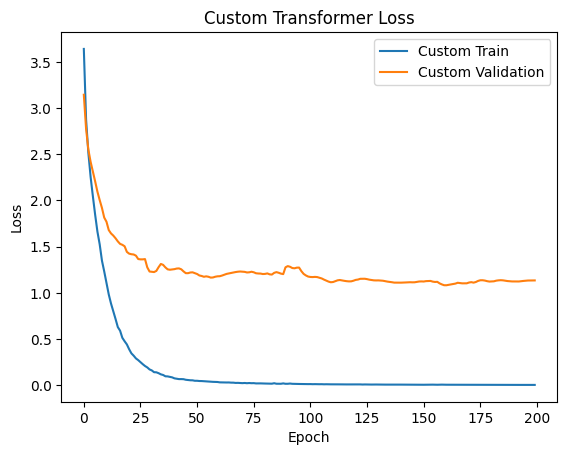

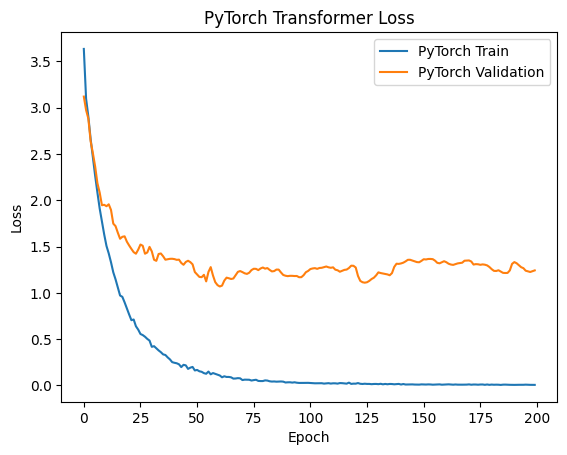

In [ ]:
# Loss Graph

import matplotlib.pyplot as plt

plt.figure()

plt.plot(
    custom_train_loss_history,
    label="Custom Train",
)

plt.plot(
    custom_val_loss_history,
    label="Custom Validation",
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title(
    "Custom Transformer Loss"
)
plt.legend()
plt.show()

# pytorch

plt.figure()

plt.plot(
    pytorch_train_loss_history,
    label="PyTorch Train",
)

plt.plot(
    pytorch_val_loss_history,
    label="PyTorch Validation",
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title(
    "PyTorch Transformer Loss"
)
plt.legend()
plt.show()

In [ ]:
# pytorch greedy decode 함수

def pytorch_greedy_decode(
    model,
    source_sentence,
    source_vocab,
    target_vocab,
    max_generation_length=20,
):
    model.eval()

    source_tokens = tokenize(
        source_sentence
    )

    source_ids = [
        BOS_IDX,
        *source_vocab.encode(
            source_tokens
        ),
        EOS_IDX,
    ]

    source_tensor = torch.tensor(
        source_ids,
        dtype=torch.long,
        device=device,
    ).unsqueeze(0)

    generated_ids = [
        BOS_IDX
    ]

    with torch.no_grad():

        for _ in range(
            max_generation_length
        ):

            target_tensor = torch.tensor(
                generated_ids,
                dtype=torch.long,
                device=device,
            ).unsqueeze(0)

            src_key_padding_mask = (
                source_tensor == PAD_IDX
            )

            tgt_key_padding_mask = (
                target_tensor == PAD_IDX
            )

            memory_key_padding_mask = (
                source_tensor == PAD_IDX
            )

            tgt_len = (
                target_tensor.size(1)
            )

            tgt_causal_mask = (
                torch.triu(
                    torch.ones(
                        tgt_len,
                        tgt_len,
                        dtype=torch.bool,
                        device=device,
                    ),
                    diagonal=1,
                )
            )

            logits = model(
                source_tensor,
                target_tensor,
                src_key_padding_mask=
                    src_key_padding_mask,
                tgt_key_padding_mask=
                    tgt_key_padding_mask,
                memory_key_padding_mask=
                    memory_key_padding_mask,
                tgt_mask=
                    tgt_causal_mask,
            )

            next_token_id = (
                logits[
                    0,
                    -1,
                ]
                .argmax()
                .item()
            )

            generated_ids.append(
                next_token_id
            )

            if (
                next_token_id
                == EOS_IDX
            ):
                break

    decoded_tokens = (
        target_vocab.decode(
            generated_ids
        )
    )

    special_tokens = {
        "<PAD>",
        "<UNK>",
        "<BOS>",
        "<EOS>",
    }

    filtered_tokens = [
        token
        for token in decoded_tokens
        if token not in special_tokens
    ]

    return " ".join(
        filtered_tokens
    )

In [ ]:
# custom greedy decode

def custom_greedy_decode(
    model,
    source_sentence,
    source_vocab,
    target_vocab,
    max_generation_length=20,
):
    model.eval()

    source_tokens = tokenize(
        source_sentence
    )

    source_ids = [
        BOS_IDX,
        *source_vocab.encode(
            source_tokens
        ),
        EOS_IDX,
    ]

    source_tensor = torch.tensor(
        source_ids,
        dtype=torch.long,
        device=device,
    ).unsqueeze(0)

    source_mask = create_padding_mask(
        source_tensor,
        PAD_IDX,
    )

    generated_ids = [
        BOS_IDX
    ]

    with torch.no_grad():

        for _ in range(
            max_generation_length
        ):

            target_tensor = torch.tensor(
                generated_ids,
                dtype=torch.long,
                device=device,
            ).unsqueeze(0)

            target_padding_mask = (
                create_padding_mask(
                    target_tensor,
                    PAD_IDX,
                )
            )

            causal_mask = (
                create_causal_mask(
                    target_tensor.size(1),
                    device=device,
                )
            )

            target_mask = (
                target_padding_mask
                & causal_mask
            )

            (
                logits,
                _,
                _,
                _,
            ) = model(
                source_tensor,
                target_tensor,
                source_mask,
                target_mask,
            )

            next_token_id = (
                logits[
                    0,
                    -1,
                ]
                .argmax()
                .item()
            )

            generated_ids.append(
                next_token_id
            )

            if (
                next_token_id
                == EOS_IDX
            ):
                break

    decoded_tokens = (
        target_vocab.decode(
            generated_ids
        )
    )

    special_tokens = {
        "<PAD>",
        "<UNK>",
        "<BOS>",
        "<EOS>",
    }

    filtered_tokens = [
        token
        for token in decoded_tokens
        if token not in special_tokens
    ]

    return " ".join(
        filtered_tokens
    )

In [ ]:
# Training / Validation 문장 비교

train_source = train_pairs[0][0]
train_reference = train_pairs[0][1]

print(
    "Source:",
    train_source,
)

print(
    "Reference:",
    train_reference,
)

print(
    "Custom:",
    custom_greedy_decode(
        custom_model,
        train_source,
        source_vocab,
        target_vocab,
    ),
)

print(
    "PyTorch:",
    pytorch_greedy_decode(
        pytorch_model,
        train_source,
        source_vocab,
        target_vocab,
    ),
)

# validation 문장

validation_source = (
    validation_pairs[0][0]
)

validation_reference = (
    validation_pairs[0][1]
)

print(
    "Source:",
    validation_source,
)

print(
    "Reference:",
    validation_reference,
)

print(
    "Custom:",
    custom_greedy_decode(
        custom_model,
        validation_source,
        source_vocab,
        target_vocab,
    ),
)

print(
    "PyTorch:",
    pytorch_greedy_decode(
        pytorch_model,
        validation_source,
        source_vocab,
        target_vocab,
    ),
)

Source: I am happy.
Reference: 나는 행복하다.
Custom: 나는 행복하다 .
PyTorch: 나는 행복하다 .
Source: I am tired.
Reference: 나는 피곤하다.
Custom: 나는 피곤하다 .
PyTorch: 나는 축구를 한다 .


In [ ]:
# 통합 테스트

assert PAD_IDX == 0
assert UNK_IDX == 1
assert BOS_IDX == 2
assert EOS_IDX == 3

assert source_vocab is not target_vocab

assert len(train_dataset) == 40
assert len(validation_dataset) == 10

source_batch, target_batch = next(
    iter(validation_loader)
)

assert (
    source_batch.dtype
    == torch.long
)

assert (
    target_batch.dtype
    == torch.long
)

decoder_input = (
    target_batch[:, :-1]
)

assert (
    decoder_input.size(1)
    ==
    target_batch.size(1) - 1
)

source_batch = source_batch.to(
    device
)

target_batch = target_batch.to(
    device
)

decoder_input = (
    target_batch[:, :-1]
)

custom_source_mask = (
    create_padding_mask(
        source_batch,
        PAD_IDX,
    )
)

custom_target_padding_mask = (
    create_padding_mask(
        decoder_input,
        PAD_IDX,
    )
)

custom_causal_mask = (
    create_causal_mask(
        decoder_input.size(1),
        device=device,
    )
)

custom_target_mask = (
    custom_target_padding_mask
    & custom_causal_mask
)

custom_model.eval()

with torch.no_grad():

    (
        custom_logits,
        _,
        _,
        _,
    ) = custom_model(
        source_batch,
        decoder_input,
        custom_source_mask,
        custom_target_mask,
    )

assert (
    custom_logits.size(-1)
    ==
    len(target_vocab)
)

src_key_padding_mask = (
    source_batch == PAD_IDX
)

tgt_key_padding_mask = (
    decoder_input == PAD_IDX
)

memory_key_padding_mask = (
    source_batch == PAD_IDX
)

tgt_len = decoder_input.size(1)

tgt_causal_mask = torch.triu(
    torch.ones(
        tgt_len,
        tgt_len,
        dtype=torch.bool,
        device=device,
    ),
    diagonal=1,
)

pytorch_model.eval()

with torch.no_grad():

    pytorch_logits = pytorch_model(
        source_batch,
        decoder_input,
        src_key_padding_mask=
            src_key_padding_mask,
        tgt_key_padding_mask=
            tgt_key_padding_mask,
        memory_key_padding_mask=
            memory_key_padding_mask,
        tgt_mask=
            tgt_causal_mask,
    )

assert (
    pytorch_logits.size(-1)
    ==
    len(target_vocab)
)

assert (
    pytorch_logits.shape[:2]
    ==
    decoder_input.shape
)

assert (
    src_key_padding_mask.shape
    ==
    source_batch.shape
)

assert (
    tgt_key_padding_mask.shape
    ==
    decoder_input.shape
)

assert (
    tgt_causal_mask.shape
    ==
    (
        decoder_input.size(1),
        decoder_input.size(1),
    )
)

test_labels = (
    target_batch[:, 1:]
)

test_loss = criterion(
    pytorch_logits.reshape(
        -1,
        pytorch_logits.size(-1),
    ),
    test_labels.reshape(-1),
)

assert torch.isfinite(
    test_loss
)

assert (
    len(custom_train_loss_history)
    == num_epochs
)

assert (
    len(custom_val_loss_history)
    == num_epochs
)

assert (
    len(pytorch_train_loss_history)
    == num_epochs
)

assert (
    len(pytorch_val_loss_history)
    == num_epochs
)

print("Final integration test passed")

Final integration test passed
